# TSP trend-gated momentum with inverse-volatility weighting

This notebook uses a configurable lookback for each TSP fund to measure both momentum and trend. Funds receive weight only when their momentum is positive and their price is above the lookback moving average. Positive momentum is divided by volatility, the resulting weights are capped, and the portfolio is scaled toward a target annualized volatility. Signals, volatility, and portfolio weights are lagged; allocations are refreshed monthly to reduce turnover.

In [12]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf
from IPython.display import display

warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.style.use('seaborn-v0_8-whitegrid')

## Configuration

Set `MANUAL_WEIGHTS` and `LOOKBACKS` independently for each investable fund. Manual weights act as allocation priors: the strategy tilts them using positive momentum and inverse volatility. A fund with a manual weight of zero is disabled and excluded from the strategy. Configure the buy-and-hold comparison separately with `PASSIVE_WEIGHTS`; it may include G Fund. `FALLBACK_FUND` is maintained separately as the strategy's defensive destination.

In [13]:
DATA_URL = 'https://www.tsp.gov/data/fund-price-history.csv'
if Path('portfolio/data').exists():
    DATA_DIR = Path('portfolio/data')
elif Path('../../portfolio/data').exists():
    DATA_DIR = Path('../../portfolio/data')
else:
    DATA_DIR = Path('data')
CACHE_PATH = DATA_DIR / 'fund-price-history.csv'
START_DATE = None  # e.g. '2010-01-01'; None uses all available common history
RISK_FREE_RATE = 0.02
TRADING_DAYS = 252
BENCHMARK_TICKER = 'SPY'

# C: S&P 500 Index
# S: Dow Jones U.S. Completion Total Stock Market Index
# I: MSCI EAFE Index (Europe, Australasia, Far East)
# F: Bloomberg U.S. Aggregate Bond Index
# G: Special non-marketable U.S. Treasury securities issued only to the TSP.

MANUAL_WEIGHTS = {
    'F Fund': 0.0,  
    'C Fund': 1.0,
    'S Fund': 0.0,
    'I Fund': 0.0,
}
PASSIVE_WEIGHTS = {
    'G Fund': 0.34,
    'F Fund': 0.00,
    'C Fund': 0.66,
    'S Fund': 0.00,
    'I Fund': 0.00,
}
LOOKBACKS = {
    'C Fund': 150,
    'F Fund': 80,
    'I Fund': 80,
    'S Fund': 100,

}
FALLBACK_FUND = 'G Fund'
VOL_LOOKBACK = 40
TARGET_ANNUAL_VOL = 0.14
VOLATILITY_POWER = 1.0  # 1.0 = inverse volatility; 0.5 = a gentler adjustment
MAX_WEIGHT = 1.0  # Maximum allocation to any one fund
REBALANCE_FREQUENCY = 'M'  # Monthly signal/weight refresh
MAX_GROSS_EXPOSURE = 1.00  # TSP portfolio; set above 1.0 only if leverage is intentional

## Download and clean TSP fund prices

In [14]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
if not CACHE_PATH.exists():
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/131.0.0.0 Safari/537.36'
        ),
        'Accept': 'text/csv,text/plain;q=0.9,*/*;q=0.8',
        'Referer': 'https://www.tsp.gov/',
    }
    response = requests.get(DATA_URL, headers=headers, timeout=30)
    response.raise_for_status()
    CACHE_PATH.write_bytes(response.content)
    print(f'Downloaded {len(response.content):,} bytes to {CACHE_PATH}')
else:
    print(f'Using cached file: {CACHE_PATH}')

raw = pd.read_csv(CACHE_PATH)
date_candidates = [
    column for column in raw.columns
    if str(column).strip().lower() in {'date', 'as of date', 'price date'}
]
date_column = date_candidates[0] if date_candidates else raw.columns[0]
raw[date_column] = pd.to_datetime(raw[date_column], errors='coerce')
prices = raw.set_index(date_column).sort_index()
prices = prices.apply(
    lambda series: pd.to_numeric(
        series.astype(str).str.replace(',', '', regex=False), errors='coerce'
    )
)
prices = prices.loc[:, prices.notna().sum() >= 20].dropna(how='all')
prices = prices[~prices.index.duplicated(keep='last')]
print(f'Data range: {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Available funds: {list(prices.columns)}')

benchmark_data = yf.download(
    BENCHMARK_TICKER,
    start=prices.index.min(),
    end=prices.index.max() + pd.Timedelta(days=1),
    auto_adjust=False,
    progress=False,
)
benchmark_prices = benchmark_data['Adj Close']
if isinstance(benchmark_prices, pd.DataFrame):
    benchmark_prices = benchmark_prices.iloc[:, 0]
benchmark_prices = pd.to_numeric(benchmark_prices, errors='coerce').sort_index().dropna()
if benchmark_prices.empty:
    raise ValueError(f'No benchmark data returned for {BENCHMARK_TICKER}.')
print(
    f'Benchmark: {BENCHMARK_TICKER} '
    f'({benchmark_prices.index.min().date()} to {benchmark_prices.index.max().date()})'
)

Using cached file: ../../portfolio/data/fund-price-history.csv
Data range: 2003-05-31 to 2026-08-21
Available funds: ['L Income', 'L 2030', 'L 2035', 'L 2040', 'L 2045', 'L 2050', 'L 2055', 'L 2060', 'L 2065', 'L 2070', 'L 2075', 'G Fund', 'F Fund', 'C Fund', 'S Fund', 'I Fund']
Benchmark: SPY (2003-06-02 to 2026-08-21)


## Build trend, momentum, inverse-volatility weights, and returns

In [15]:
weights = pd.Series(MANUAL_WEIGHTS, dtype=float)
weights.index = weights.index.map(str).str.strip()
weights = weights.groupby(level=0).sum()
if weights.empty or not np.isfinite(weights).all() or (weights < 0).any():
    raise ValueError('MANUAL_WEIGHTS must contain non-negative numeric values.')
if weights.sum() <= 0:
    raise ValueError('MANUAL_WEIGHTS must sum to a positive value.')
# The fallback fund is not an optimizer input. If supplied accidentally, ignore it.
if FALLBACK_FUND in weights.index:
    print(f'Ignoring {FALLBACK_FUND} in MANUAL_WEIGHTS; it is fallback-only.')
    weights = weights.drop(index=FALLBACK_FUND)
if weights.sum() <= 0:
    raise ValueError('MANUAL_WEIGHTS must contain at least one positive non-fallback fund.')
weights = weights / weights.sum()
# Zero-weight funds are intentionally removed from every strategy calculation.
weights = weights[weights > 0]

passive_weights = pd.Series(PASSIVE_WEIGHTS, dtype=float)
passive_weights.index = passive_weights.index.map(str).str.strip()
passive_weights = passive_weights.groupby(level=0).sum()
if passive_weights.empty or not np.isfinite(passive_weights).all() or (passive_weights < 0).any():
    raise ValueError('PASSIVE_WEIGHTS must contain non-negative numeric values.')
if passive_weights.sum() <= 0:
    raise ValueError('PASSIVE_WEIGHTS must sum to a positive value.')
passive_weights = passive_weights / passive_weights.sum()
passive_weights = passive_weights[passive_weights > 0]

required_funds = set(weights.index) | set(passive_weights.index) | {FALLBACK_FUND}
missing_funds = sorted(required_funds - set(prices.columns))
if missing_funds:
    raise ValueError(f'Funds missing from TSP data: {missing_funds}')
missing_lookbacks = sorted(set(weights.index) - set(LOOKBACKS))
if missing_lookbacks:
    raise ValueError(f'Missing lookbacks for: {missing_lookbacks}')
lookbacks = {fund: int(LOOKBACKS[fund]) for fund in weights.index}
if any(lookback < 2 for lookback in lookbacks.values()):
    raise ValueError('Each lookback must be at least 2 trading days.')
if FALLBACK_FUND not in prices.columns:
    raise ValueError(f'FALLBACK_FUND not found in TSP data: {FALLBACK_FUND}')

strategy_funds = list(dict.fromkeys(
    list(weights.index) + [FALLBACK_FUND] + list(passive_weights.index)
))
selected_prices = prices.loc[:, strategy_funds].dropna()
if START_DATE is not None:
    selected_prices = selected_prices.loc[pd.Timestamp(START_DATE):]
if len(selected_prices) < max(max(lookbacks.values()), VOL_LOOKBACK) + 2:
    raise ValueError('Not enough common history for the configured lookbacks.')

fund_returns = selected_prices.pct_change().dropna()

# Every signal uses information available before the return being traded.
signals = pd.DataFrame(index=selected_prices.index, columns=weights.index, dtype=float)
momentum = pd.DataFrame(index=selected_prices.index, columns=weights.index, dtype=float)
for fund, lookback in lookbacks.items():
    moving_average = selected_prices[fund].rolling(lookback).mean()
    signals[fund] = selected_prices[fund].gt(moving_average).shift(1).astype(float)
    momentum[fund] = selected_prices[fund].pct_change(lookback).shift(1)
signals = signals.reindex(fund_returns.index).fillna(0.0)
momentum = momentum.reindex(fund_returns.index)
fund_volatility = (
    fund_returns.rolling(VOL_LOOKBACK).std().shift(1) * np.sqrt(TRADING_DAYS)
)

# Positive momentum is risk-adjusted by each fund's own volatility.
risk_adjusted_score = (
    momentum.clip(lower=0.0)
    .mul(signals)
    .div(fund_volatility.pow(VOLATILITY_POWER))
)
risk_adjusted_score = risk_adjusted_score.replace([np.inf, -np.inf], np.nan).fillna(0.0)
raw_weights = risk_adjusted_score.mul(weights, axis=1)
candidate_weights = raw_weights.div(
    raw_weights.sum(axis=1).replace(0, np.nan), axis=0
).fillna(0.0)
candidate_weights[FALLBACK_FUND] = 0.0
no_active_signal = raw_weights.sum(axis=1).eq(0)
candidate_weights.loc[no_active_signal, FALLBACK_FUND] = 1.0

def cap_and_normalize(row, cap=MAX_WEIGHT):
    """Cap fund weights while redistributing excess to uncapped funds."""
    row = row.clip(lower=0.0).fillna(0.0)
    if row.sum() <= 0:
        row[:] = 0.0
        row[FALLBACK_FUND] = 1.0
        return row
    row = row / row.sum()
    for _ in range(len(row) + 1):
        over_cap = row > cap
        if not over_cap.any():
            break
        excess = (row[over_cap] - cap).sum()
        row[over_cap] = cap
        available = (~over_cap) & (row < cap)
        if not available.any():
            break
        available_total = row[available].sum()
        if available_total > 0:
            row[available] += excess * row[available] / available_total
        else:
            prior = weights.reindex(row.index).fillna(0.0)
            prior = prior.where(available, 0.0)
            if prior.sum() <= 0:
                prior.loc[FALLBACK_FUND] = 1.0
                prior = prior.where(available, 0.0)
            row[available] += excess * prior / prior.sum()
    return row / row.sum()

if not 0 < MAX_WEIGHT <= 1:
    raise ValueError('MAX_WEIGHT must be between 0 and 1.')
effective_max_weight = max(MAX_WEIGHT, 1.0 / len(weights))
if effective_max_weight > MAX_WEIGHT:
    print(
        f'MAX_WEIGHT raised to {effective_max_weight:.2%}: '
        f'{len(weights)} enabled funds require at least this cap.'
    )
candidate_weights = candidate_weights.apply(
    lambda row: cap_and_normalize(row, effective_max_weight), axis=1
)
candidate_weights.loc[no_active_signal, :] = 0.0
candidate_weights.loc[no_active_signal, FALLBACK_FUND] = 1.0

# Refresh target weights monthly, then hold them until the next rebalance.
periods = pd.Series(fund_returns.index.to_period(REBALANCE_FREQUENCY), index=fund_returns.index)
rebalance_dates = periods.ne(periods.shift(1)).fillna(True)
strategy_weights = candidate_weights.where(rebalance_dates, np.nan).ffill()
strategy_weights = strategy_weights.fillna(candidate_weights)

base_returns = fund_returns.mul(strategy_weights).sum(axis=1)
portfolio_volatility = (
    base_returns.rolling(VOL_LOOKBACK).std().shift(1) * np.sqrt(TRADING_DAYS)
)
exposure = TARGET_ANNUAL_VOL / portfolio_volatility.replace(0, np.nan)
exposure = (
    exposure.replace([np.inf, -np.inf], np.nan)
    .fillna(1.0)
    .clip(lower=0.0, upper=MAX_GROSS_EXPOSURE)
)
strategy_returns = (base_returns * exposure).dropna()
passive_returns = fund_returns.mul(passive_weights, axis=1).sum(axis=1)
benchmark_returns = benchmark_prices.pct_change().rename(BENCHMARK_TICKER)
common_index = strategy_returns.index.intersection(benchmark_returns.index)
if common_index.empty:
    raise ValueError(f'No overlapping dates between TSP data and {BENCHMARK_TICKER}.')
strategy_returns = strategy_returns.reindex(common_index)
passive_returns = passive_returns.reindex(common_index)
benchmark_returns = benchmark_returns.reindex(common_index)
strategy_equity = (1 + strategy_returns).cumprod()
passive_equity = (1 + passive_returns).cumprod()
benchmark_equity = (1 + benchmark_returns).cumprod()

print(f'Lookbacks: {lookbacks}')
print(f'Target annual volatility: {TARGET_ANNUAL_VOL:.2%}')
print(f'Average exposure: {exposure.loc[strategy_returns.index].mean():.2%}')
print(f'Rebalances: {int(rebalance_dates.loc[strategy_returns.index].sum())}')
display(weights.rename('Base Weight').to_frame().style.format('{:.2%}'))
display(passive_weights.rename('Passive Weight').to_frame().style.format('{:.2%}'))
display(strategy_weights.mean().rename('Average Strategy Weight').to_frame().style.format('{:.2%}'))
display(signals[weights.index].mean().rename('Trend Active Fraction').to_frame().style.format('{:.2%}'))

Lookbacks: {'C Fund': 150}
Target annual volatility: 14.00%
Average exposure: 96.56%
Rebalances: 279


,Base Weight
C Fund,100.00%


,Passive Weight
C Fund,66.00%
G Fund,34.00%


,Average Strategy Weight
C Fund,74.08%
G Fund,25.92%


,Trend Active Fraction
C Fund,76.69%


## Performance metrics

In [16]:
def performance_metrics(equity, risk_free=RISK_FREE_RATE):
    equity = equity.dropna()
    returns = equity.pct_change().dropna()
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    drawdown = equity / equity.cummax() - 1
    max_dd = drawdown.min()
    daily_rf = (1 + risk_free) ** (1 / TRADING_DAYS) - 1
    excess = returns - daily_rf
    volatility = returns.std(ddof=1)
    sharpe = np.sqrt(TRADING_DAYS) * excess.mean() / volatility if volatility > 0 else np.nan
    downside = np.minimum(excess, 0)
    downside_dev = np.sqrt(np.mean(downside ** 2))
    sortino = np.sqrt(TRADING_DAYS) * excess.mean() / downside_dev if downside_dev > 0 else np.nan
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    return pd.Series({
        'CAGR': cagr, 'Sharpe': sharpe, 'MaxDD': max_dd,
        'Sortino': sortino, 'Calmar': calmar, 'Years': years,
    })

metrics = pd.DataFrame({
    'Trend + Inverse-Vol Strategy': performance_metrics(strategy_equity),
    'Passive Manual Portfolio': performance_metrics(passive_equity),
    f'{BENCHMARK_TICKER} Benchmark': performance_metrics(benchmark_equity),
}).T
display(metrics.style.format({
    'CAGR': '{:.2%}', 'Sharpe': '{:.2f}', 'MaxDD': '{:.2%}',
    'Sortino': '{:.2f}', 'Calmar': '{:.2f}', 'Years': '{:.1f}',
}))

,CAGR,Sharpe,MaxDD,Sortino,Calmar,Years
Trend + Inverse-Vol Strategy,9.70%,0.74,-17.06%,1.02,0.57,23.2
Passive Manual Portfolio,8.94%,0.60,-38.70%,0.84,0.23,23.2
SPY Benchmark,10.40%,0.53,-59.22%,0.73,0.18,23.2


## Historical growth

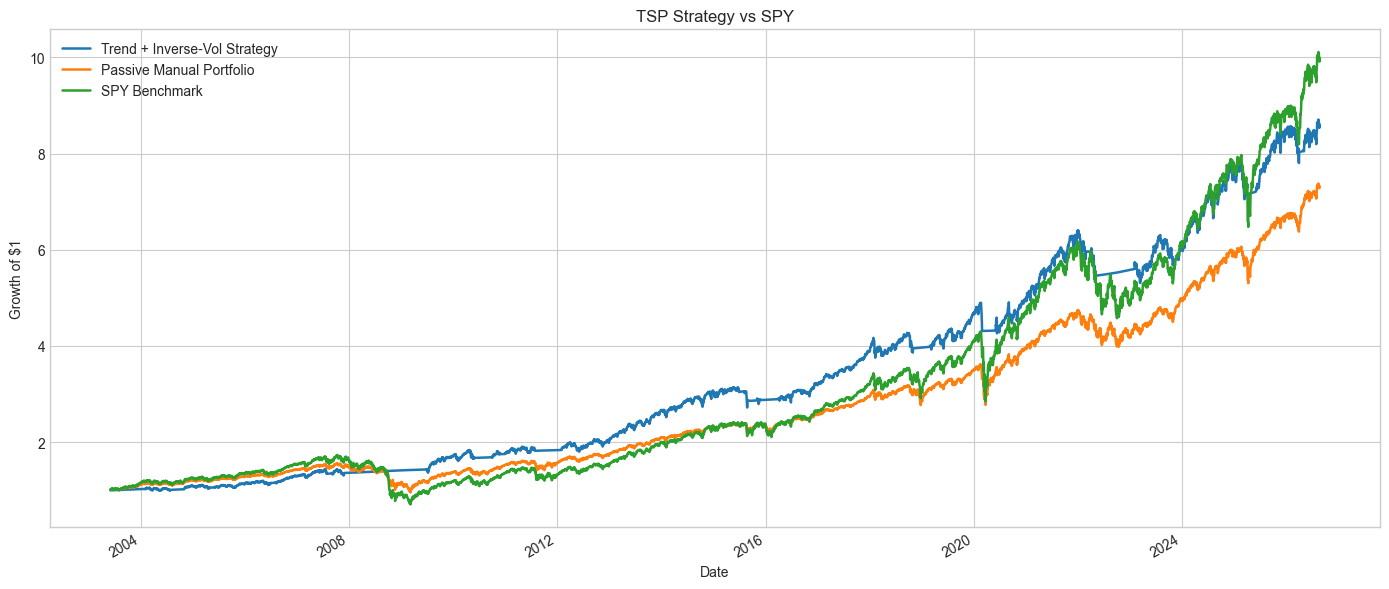

In [17]:
equity = pd.concat(
    [
        strategy_equity.rename('Trend + Inverse-Vol Strategy'),
        passive_equity.rename('Passive Manual Portfolio'),
        benchmark_equity.rename(f'{BENCHMARK_TICKER} Benchmark'),
    ],
    axis=1,
).dropna()
ax = equity.plot(figsize=(14, 6), linewidth=1.8, title=f'TSP Strategy vs {BENCHMARK_TICKER}')
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()